## Code parameters from paper (page-11)

1) Assume MaxCut, so q=2 (Pott's formulation -> general ising for any order interactions)
2) W: adjacency/weight matrix, shape (n, n) => Symmetric, W[i,j]=weight.
3) batch: number of replicas m.
4) h: learnable “logits / local fields”, shape (batch, n, q)
5) p = softmax(h, dim=2): probabilities, shape (batch, n, q). For each replica r and node i: p[r,i,0] + p[r,i,1] = 1

So each replica is a full probabilistic solution.

In [1]:
import torch
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

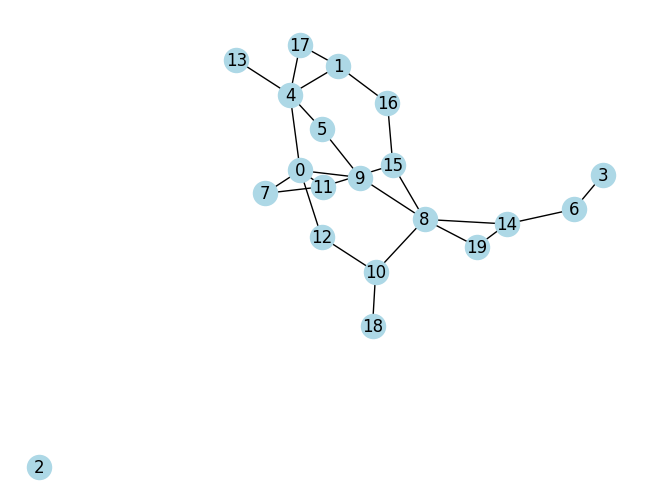

W shape: (20, 20)
Unique values in W: [0. 1.]


In [2]:
# GRAPH UTILITIES
def random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1): # generate random undirected graph
    G = nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=False)
    return G
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W

def draw_cut(G, x, seed=42):
    pos = nx.spring_layout(G, seed=seed)

    # node colors: 0 -> one color, 1 -> another
    node_colors = ["tab:blue" if x[i] == 0 else "tab:orange" for i in G.nodes()]

    # edge colors: cut edges in red, others in light gray
    edge_colors = []
    for u, v in G.edges():
        edge_colors.append("tab:red" if x[u] != x[v] else "lightgray")

    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, width=2)
    plt.show()

# generate graph
G = random_binary_undirected_graph(n_nodes=20, edge_prob=0.1, seed=7)
draw_graph(G)
# adjacency matrix
W = graph_to_binary_adjacency(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

In [3]:
# --- device ---
device = "mps" if torch.backends.mps.is_available() else "cpu"

# --- graph ---
W = torch.tensor(W, dtype=torch.float32).to(device)

# --- hyperparameters ---
batch = 64
q = 2
n = W.shape[0]
beta_range = torch.linspace(0.5, 20.0, steps=200).to(device)

# --- learnable fields ---
h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))
device

'mps'

In [4]:
def cut(W, p):
    # W: (n,n), p: (batch,n,q)
    return ((W @ p) * (1 - p)).sum((1, 2))

def S(p, eps=1e-12):
    p = p.clamp_min(eps)
    return -(p * p.log()).sum(2).sum(1)

def argmax_cut(W, p):
    config = p.argmax(dim=2)  # (batch,n)
    s = F.one_hot(config, num_classes=p.shape[2]).float()
    return config, cut(W, s) / 2

def solve_maxcut(W, batch=64, lr=0.01, steps=200):
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    W = torch.tensor(W, dtype=torch.float32).to(device)
    n = W.shape[0]
    q = 2
    h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))
    optimizer = torch.optim.Adam([h], lr=lr)
    beta_range = torch.linspace(0.5, 20.0, steps=steps).to(device)

    for beta in beta_range:
        p = torch.softmax(h, dim=2)
        Fval = -cut(W, p) - S(p) / beta

        optimizer.zero_grad()
        Fval.backward(torch.ones_like(Fval))
        optimizer.step()

    p_final = torch.softmax(h, dim=2)
    config, cutvals = argmax_cut(W, p_final)
    return config, cutvals, p_final, h.detach()

In [5]:
# solve
config, cutvals, p, h_final = solve_maxcut(W, batch=64, steps=500)

# pick best replica r*
best = cutvals.argmax().item()
p_best = p[best]
h_best = h_final[best]

W_cpu = W.detach().cpu() if W.device.type != "cpu" else W
p_best_cpu = p_best.detach().cpu()
h_best_cpu = h_best.detach().cpu()


# local scores: (n,)
score0 = (W_cpu @ p_best_cpu[:, 1])  # sum_j W_ij * p_j(1)
score1 = (W_cpu @ p_best_cpu[:, 0])  # sum_j W_ij * p_j(0)
local_argmax = (score1 > score0).int()  # 1 if score1 bigger else 0

best_cut = cutvals[best].item()
best_config = local_argmax

print("Best cut value:", best_cut)
print("h_best:\n", h_best_cpu)
print("p_best:\n", p_best_cpu)
#print("score0:", score0)
#print("score1:", score1)
print("local_argmax partition:", local_argmax.numpy())


/var/folders/hs/wzcwdwgd39lbf4_c_gqzw19r0000gn/T/ipykernel_21092/975283285.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  W = torch.tensor(W, dtype=torch.float32).to(device)


Best cut value: 21.0
h_best:
 tensor([[-2.1107,  2.9401],
        [ 2.9272, -1.9563],
        [ 0.7249,  0.7249],
        [-2.3052,  2.9579],
        [ 3.2870, -2.0878],
        [-2.2046,  3.0982],
        [ 3.2043, -2.1403],
        [ 2.9848, -2.4139],
        [-2.2282,  3.1700],
        [ 2.7757, -2.4245],
        [ 3.2276, -1.9642],
        [-2.0187,  2.8305],
        [ 0.0722,  0.1415],
        [-2.1716,  2.9083],
        [-2.1639,  3.1252],
        [ 2.9839, -2.1013],
        [-2.0344,  3.5241],
        [-1.9455,  3.6858],
        [-1.6003,  2.9649],
        [ 3.0184, -2.5136]])
p_best:
 tensor([[0.0064, 0.9936],
        [0.9925, 0.0075],
        [0.5000, 0.5000],
        [0.0052, 0.9948],
        [0.9954, 0.0046],
        [0.0050, 0.9950],
        [0.9952, 0.0048],
        [0.9955, 0.0045],
        [0.0045, 0.9955],
        [0.9945, 0.0055],
        [0.9945, 0.0055],
        [0.0078, 0.9922],
        [0.4827, 0.5173],
        [0.0062, 0.9938],
        [0.0050, 0.9950],
        [0

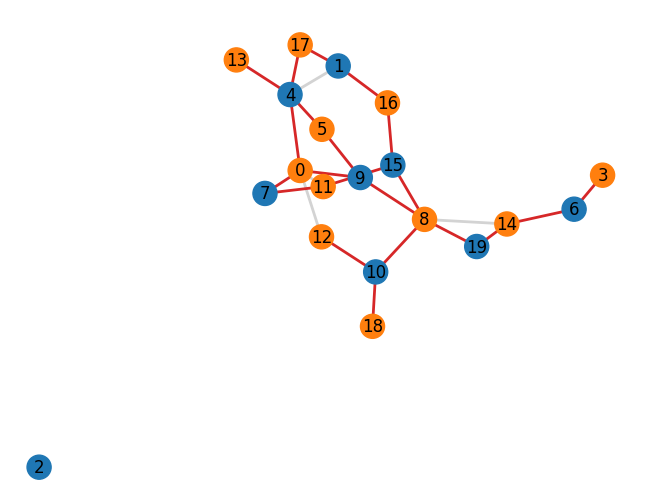

,logit_0,logit_1,marginal_p(0),marginal_p(1)
0,-2.110682,2.940116,0.006363,0.993637
1,2.927197,-1.956345,0.992487,0.007513
2,0.724918,0.724916,0.500000,0.500000
3,-2.305208,2.957857,0.005153,0.994847
4,3.286971,-2.087780,0.995389,0.004611
5,-2.204595,3.098217,0.004953,0.995047
6,3.204253,-2.140283,0.995248,0.004751
7,2.984831,-2.413937,0.995498,0.004502
8,-2.228163,3.170043,0.004504,0.995496
9,2.775714,-2.424506,0.994515,0.005485


In [6]:
x = best_config.cpu().numpy()
import pandas as pd
def maxcut_marginals_dataframe(h_best, p_best):
    n = h_best.shape[0]
    df = pd.DataFrame({
        "logit_0": h_best_cpu[:, 0],
        "logit_1": h_best_cpu[:, 1],
        "marginal_p(0)": p_best_cpu[:, 0],
        "marginal_p(1)": p_best_cpu[:, 1],
    })
    return df

# ---- usage ----
df_maxcut = maxcut_marginals_dataframe(h_best, p_best)
draw_cut(G,x)
df_maxcut